We start with the data set provided from [UCI Machine Learning Repository: Spambase Data Set](https://archive.ics.uci.edu/dataset/94/spambase). We can see that the data provided gives the frequency for 48 different words, 6 different characters (mostly symbols), the length of continuous capital letters in 3 different forms, and finally the classification of spam/ham. Each entry is an individual email and the frequency is how many times these appear in the email. 

In [1]:
import numpy as np
import pandas as pd
# import seaborn as sns
# import nltk
# import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

Here we import the data and assign it to a `pandas` dataframe and ensure it is labeled.

In [2]:
names = pd.read_csv("spambase1.names", header = None)
data = pd.read_csv("spambase.data", delimiter=',', header = None, names = names[0])

data.head(5).T

,0,1,2,3,4
word_freq_make,0.000,0.210,0.060,0.000,0.000
word_freq_address,0.640,0.280,0.000,0.000,0.000
word_freq_all,0.640,0.500,0.710,0.000,0.000
word_freq_3d,0.000,0.000,0.000,0.000,0.000
word_freq_our,0.320,0.140,1.230,0.630,0.630
word_freq_over,0.000,0.280,0.190,0.000,0.000
word_freq_remove,0.000,0.210,0.190,0.310,0.310
word_freq_internet,0.000,0.070,0.120,0.630,0.630
word_freq_order,0.000,0.000,0.640,0.310,0.310
word_freq_mail,0.000,0.940,0.250,0.630,0.630


To get a better idea of the impact of individual predictors on the classification of spam and ham by grouping by spam and ham and taking the average value for each predictor.

In [3]:
mean_data = data.groupby(by='spam').agg('mean').T.sort_values(1, ascending = False)
mean_data

spam,0,1
capital_run_length_total,161.470947,470.619415
capital_run_length_longest,18.214491,104.393271
capital_run_length_average,2.377301,9.519165
word_freq_you,1.270341,2.264539
word_freq_your,0.438702,1.380370
word_freq_will,0.536324,0.549972
word_freq_free,0.073587,0.518362
word_freq_our,0.181040,0.513955
char_freq_!,0.109984,0.513713
word_freq_all,0.200581,0.403795


We also want to try and see if the median works better than the mean but we can see a lot of the medians are zero which do not provide a lot of benefit for this analysis.

In [4]:
median_data = data.groupby(by='spam').agg('median').T.sort_values(1, ascending = False)
median_data

spam,0,1
capital_run_length_total,54.0000,194.000
capital_run_length_longest,10.0000,38.000
capital_run_length_average,1.8570,3.621
word_freq_you,0.5100,2.180
word_freq_your,0.0000,1.190
word_freq_will,0.0000,0.430
char_freq_!,0.0000,0.331
word_freq_all,0.0000,0.300
word_freq_our,0.0000,0.290
word_freq_free,0.0000,0.140


To see the frequencies of words most highly associated with spam over ham we can create a bar graph of all the mean values prioritizing the sorting of the spam since that what we should focus on.

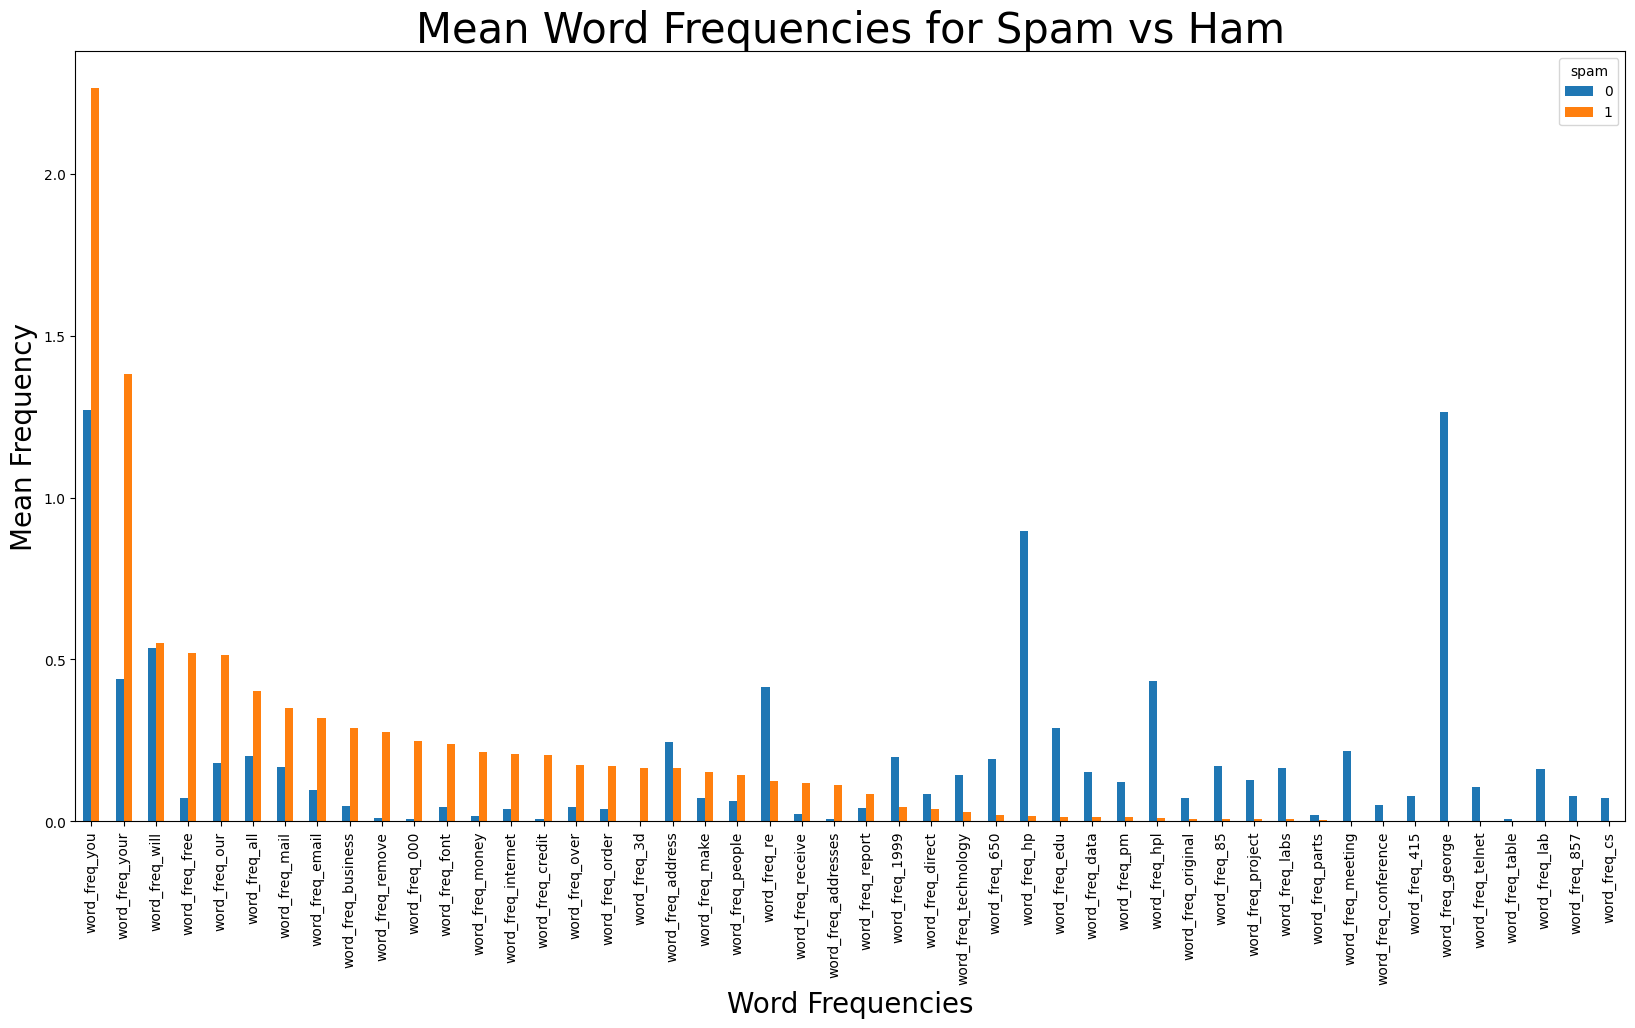

In [5]:
fig, ax = plt.subplots(figsize = (20,10))
plt.title('Mean Word Frequencies for Spam vs Ham' , size = 30)
plt.xlabel('Word Frequencies', size = 20)
plt.ylabel('Mean Frequency', size = 20)

mean_data.T.filter(like = 'word_').T.plot.bar(ax=ax)
plt.show()

Next we can plot the frequencies of the characters since their distribution is expected to be different from the words, the spam numbers are also prioritized here.

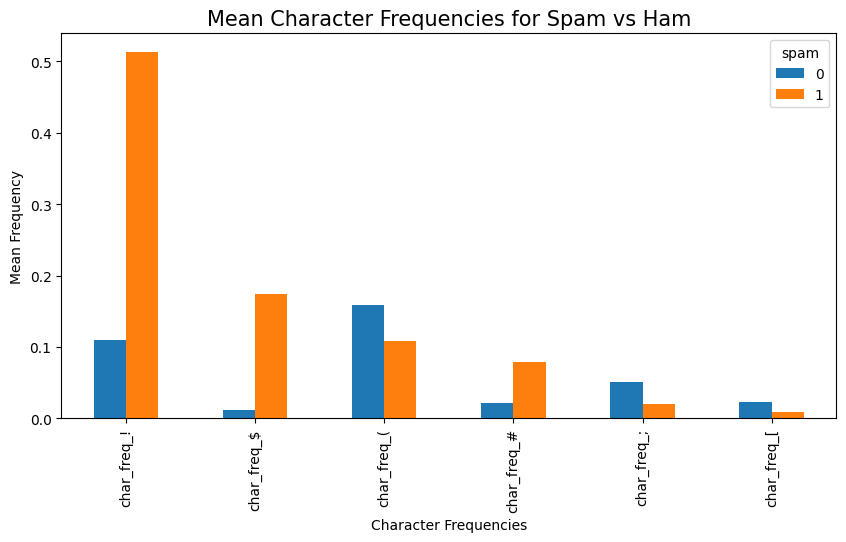

In [6]:
fig, ax = plt.subplots(figsize = (10,5))
plt.title('Mean Character Frequencies for Spam vs Ham' , size = 15)
plt.xlabel('Character Frequencies', size = 10)
plt.ylabel('Mean Frequency', size = 10)

mean_data.T.filter(like = 'char_').T.plot.bar(ax=ax)
plt.show()

Finally we make the same graph for the capital predictors to see which is most influential.

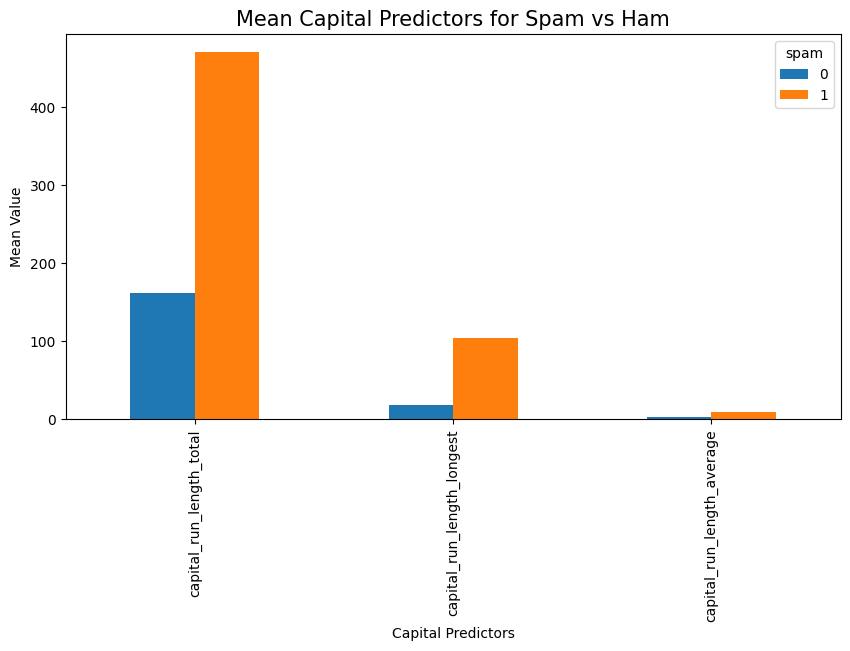

In [7]:
fig, ax = plt.subplots(figsize = (10,5))
plt.title('Mean Capital Predictors for Spam vs Ham' , size = 15)
plt.xlabel('Capital Predictors', size = 10)
plt.ylabel('Mean Value', size = 10)

mean_data.T.filter(like = 'capital_').T.plot.bar(ax=ax)
plt.show()

These distributions can show us which predictors may be good for telling us which emails are spam or ham. For example, `word_freq_you`, `char_freq_!`, `capital_run_length_total` have pretty high averages for spam over ham so they will likely be good predictors. But just because they have high averages doesn't mean that relative to the ham it is easier to use as a predictor.

In [8]:
mean_data['ratio'] = mean_data[1]/mean_data[0]
mean_data = mean_data.sort_values('ratio', ascending = False)

To show which predictors have higher averages for spam relative to ham we can take the ratio of the two values and then make a graph of those values.

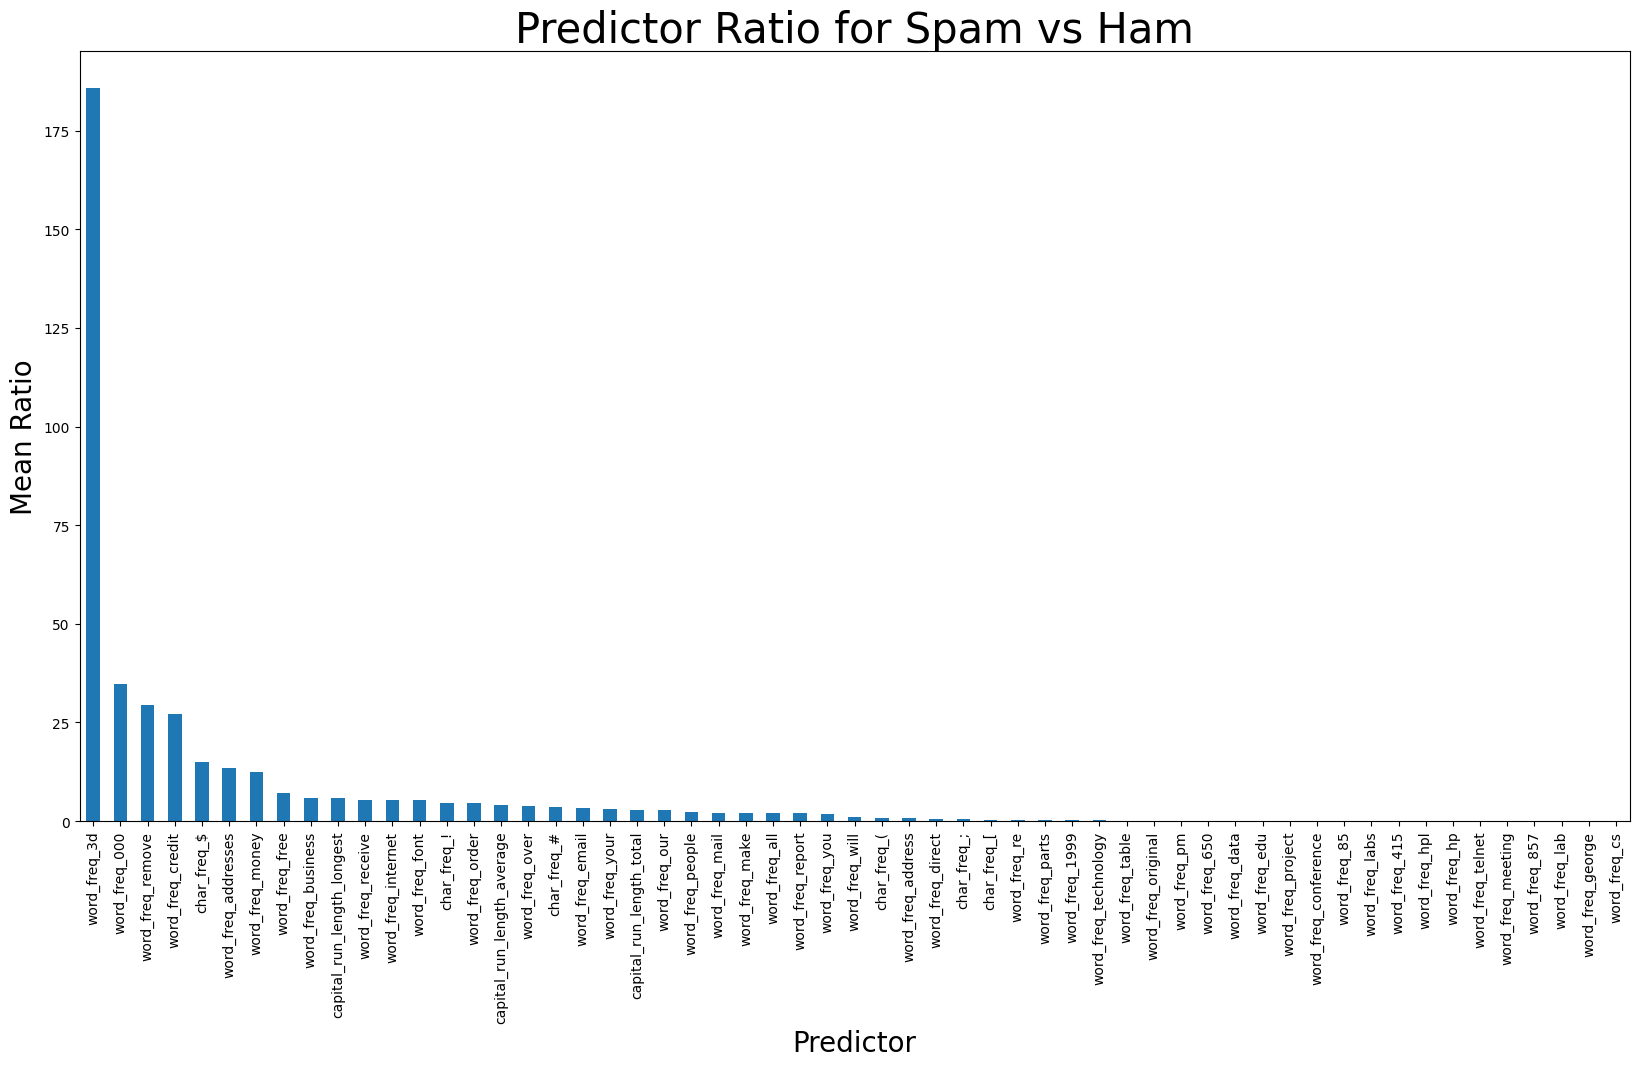

In [9]:
fig, ax = plt.subplots(figsize = (20,10))
plt.title('Predictor Ratio for Spam vs Ham' , size = 30)
plt.xlabel('Predictor', size = 20)
plt.ylabel('Mean Ratio', size = 20)

mean_data['ratio'].plot.bar(ax=ax)
plt.show()

We can define a function to create individual random forest models to see which is most impactful given the number of predictors.

In [10]:
def randomForest(X,y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=314)

    rf = RandomForestClassifier(n_estimators=100, random_state=314)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    # print('Accuracy score: {:.2f}%'.format(acc * 100))

    return acc, y_pred

y = data['spam'].values

Here we can see that the number of predictors definitely has an impact of the accuracy score of the model with marginal returns the more predictors that get added.

In [11]:
cols = data.columns

acc_lst = []
for i in range(1,57):
    X = data[cols[:i]].values
    acc, y_pred = randomForest(X,y)
    acc_lst.append([i,acc*100])

for ea in acc_lst:
    print('Feature set {}'.format(ea[0]) + ' accuracy score: {:.2f}%'.format(ea[1]))

Feature set 1 accuracy score: 65.25%
Feature set 2 accuracy score: 70.46%
Feature set 3 accuracy score: 72.55%
Feature set 4 accuracy score: 72.98%
Feature set 5 accuracy score: 75.50%
Feature set 6 accuracy score: 77.41%
Feature set 7 accuracy score: 82.71%
Feature set 8 accuracy score: 84.36%
Feature set 9 accuracy score: 84.45%
Feature set 10 accuracy score: 85.49%
Feature set 11 accuracy score: 85.66%
Feature set 12 accuracy score: 86.19%
Feature set 13 accuracy score: 86.62%
Feature set 14 accuracy score: 86.19%
Feature set 15 accuracy score: 86.53%
Feature set 16 accuracy score: 88.27%
Feature set 17 accuracy score: 88.71%
Feature set 18 accuracy score: 88.44%
Feature set 19 accuracy score: 90.79%
Feature set 20 accuracy score: 90.01%
Feature set 21 accuracy score: 90.36%
Feature set 22 accuracy score: 90.79%
Feature set 23 accuracy score: 90.96%
Feature set 24 accuracy score: 91.57%
Feature set 25 accuracy score: 91.75%
Feature set 26 accuracy score: 91.66%
Feature set 27 accura

We can see by graphing the accuracy scores for the number of predictors. The 14 and 28 predictor models have the some of the highest accuracy scores relative to the other number of predictors around it. More predictors either marginally improves the accuracy score or even makes it worse. 

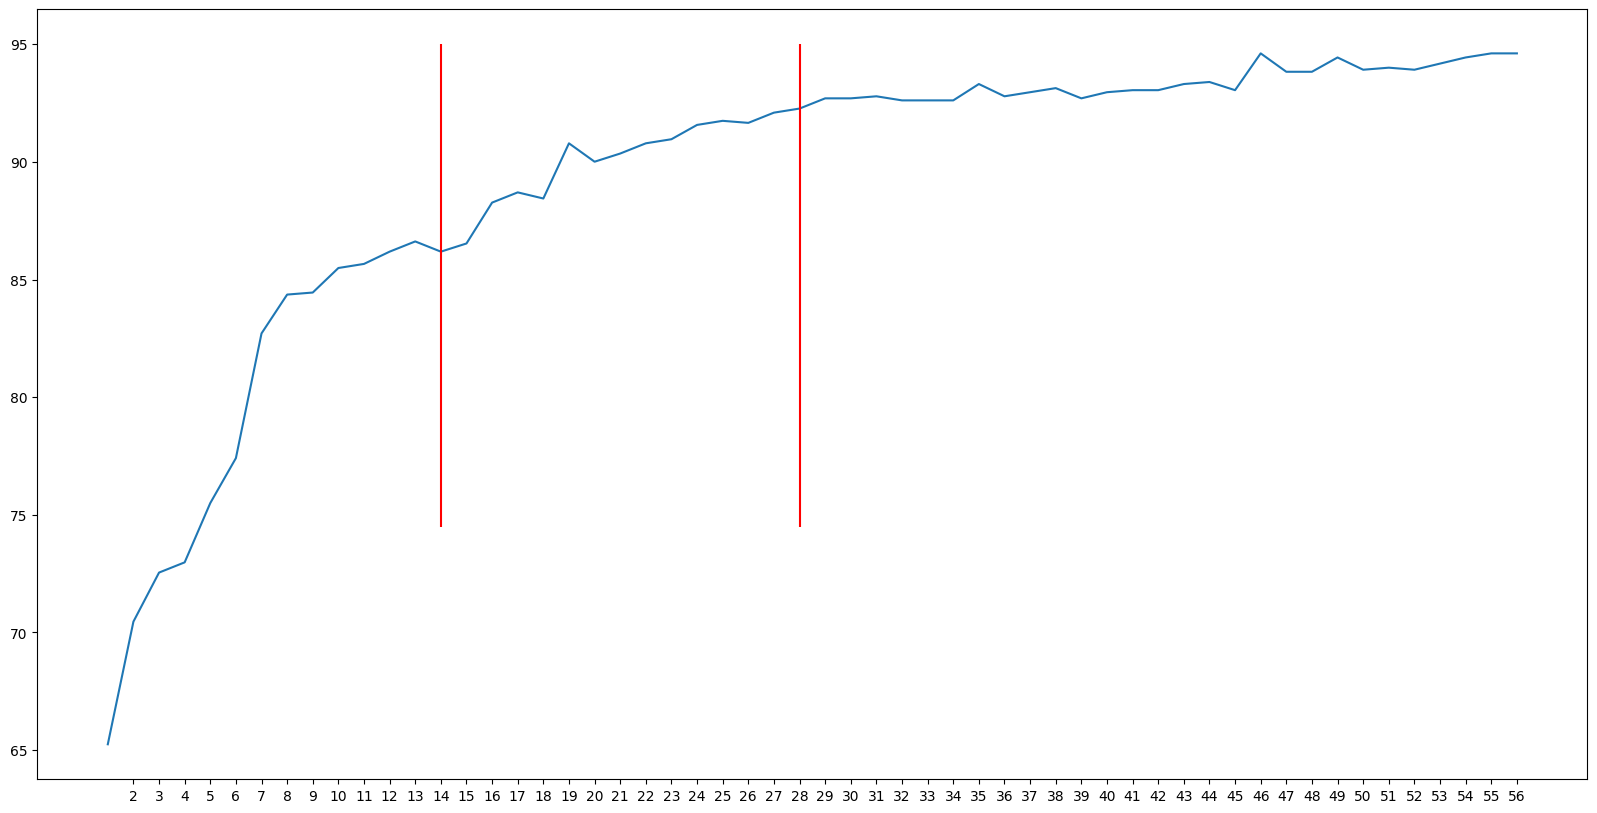

In [12]:
acc_df = pd.DataFrame(acc_lst, columns = ['feature', 'accuracy'])

plt.figure(figsize = (20,10))
plt.plot(acc_df['feature'], acc_df['accuracy'])
plt.vlines(x=[14,28], ymin = 74.5, ymax = 95, color = 'red')
plt.xticks(np.arange(2, 57, 1)) 
plt.show()

To determine the best set of predictors we can start by adding all predictors to a model and then testing to see which predictors are the most influences on the model by using the `feature_importances_` for random forests. Here is the first model with all the predictors.

In [13]:
X = data[cols[:57]].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=314)

rf = RandomForestClassifier(n_estimators=100, random_state=314)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

This graph shows what it looks like for the distribution of the feature importance. We can an exponential distribution and that the least influential features have very little influence on the model.

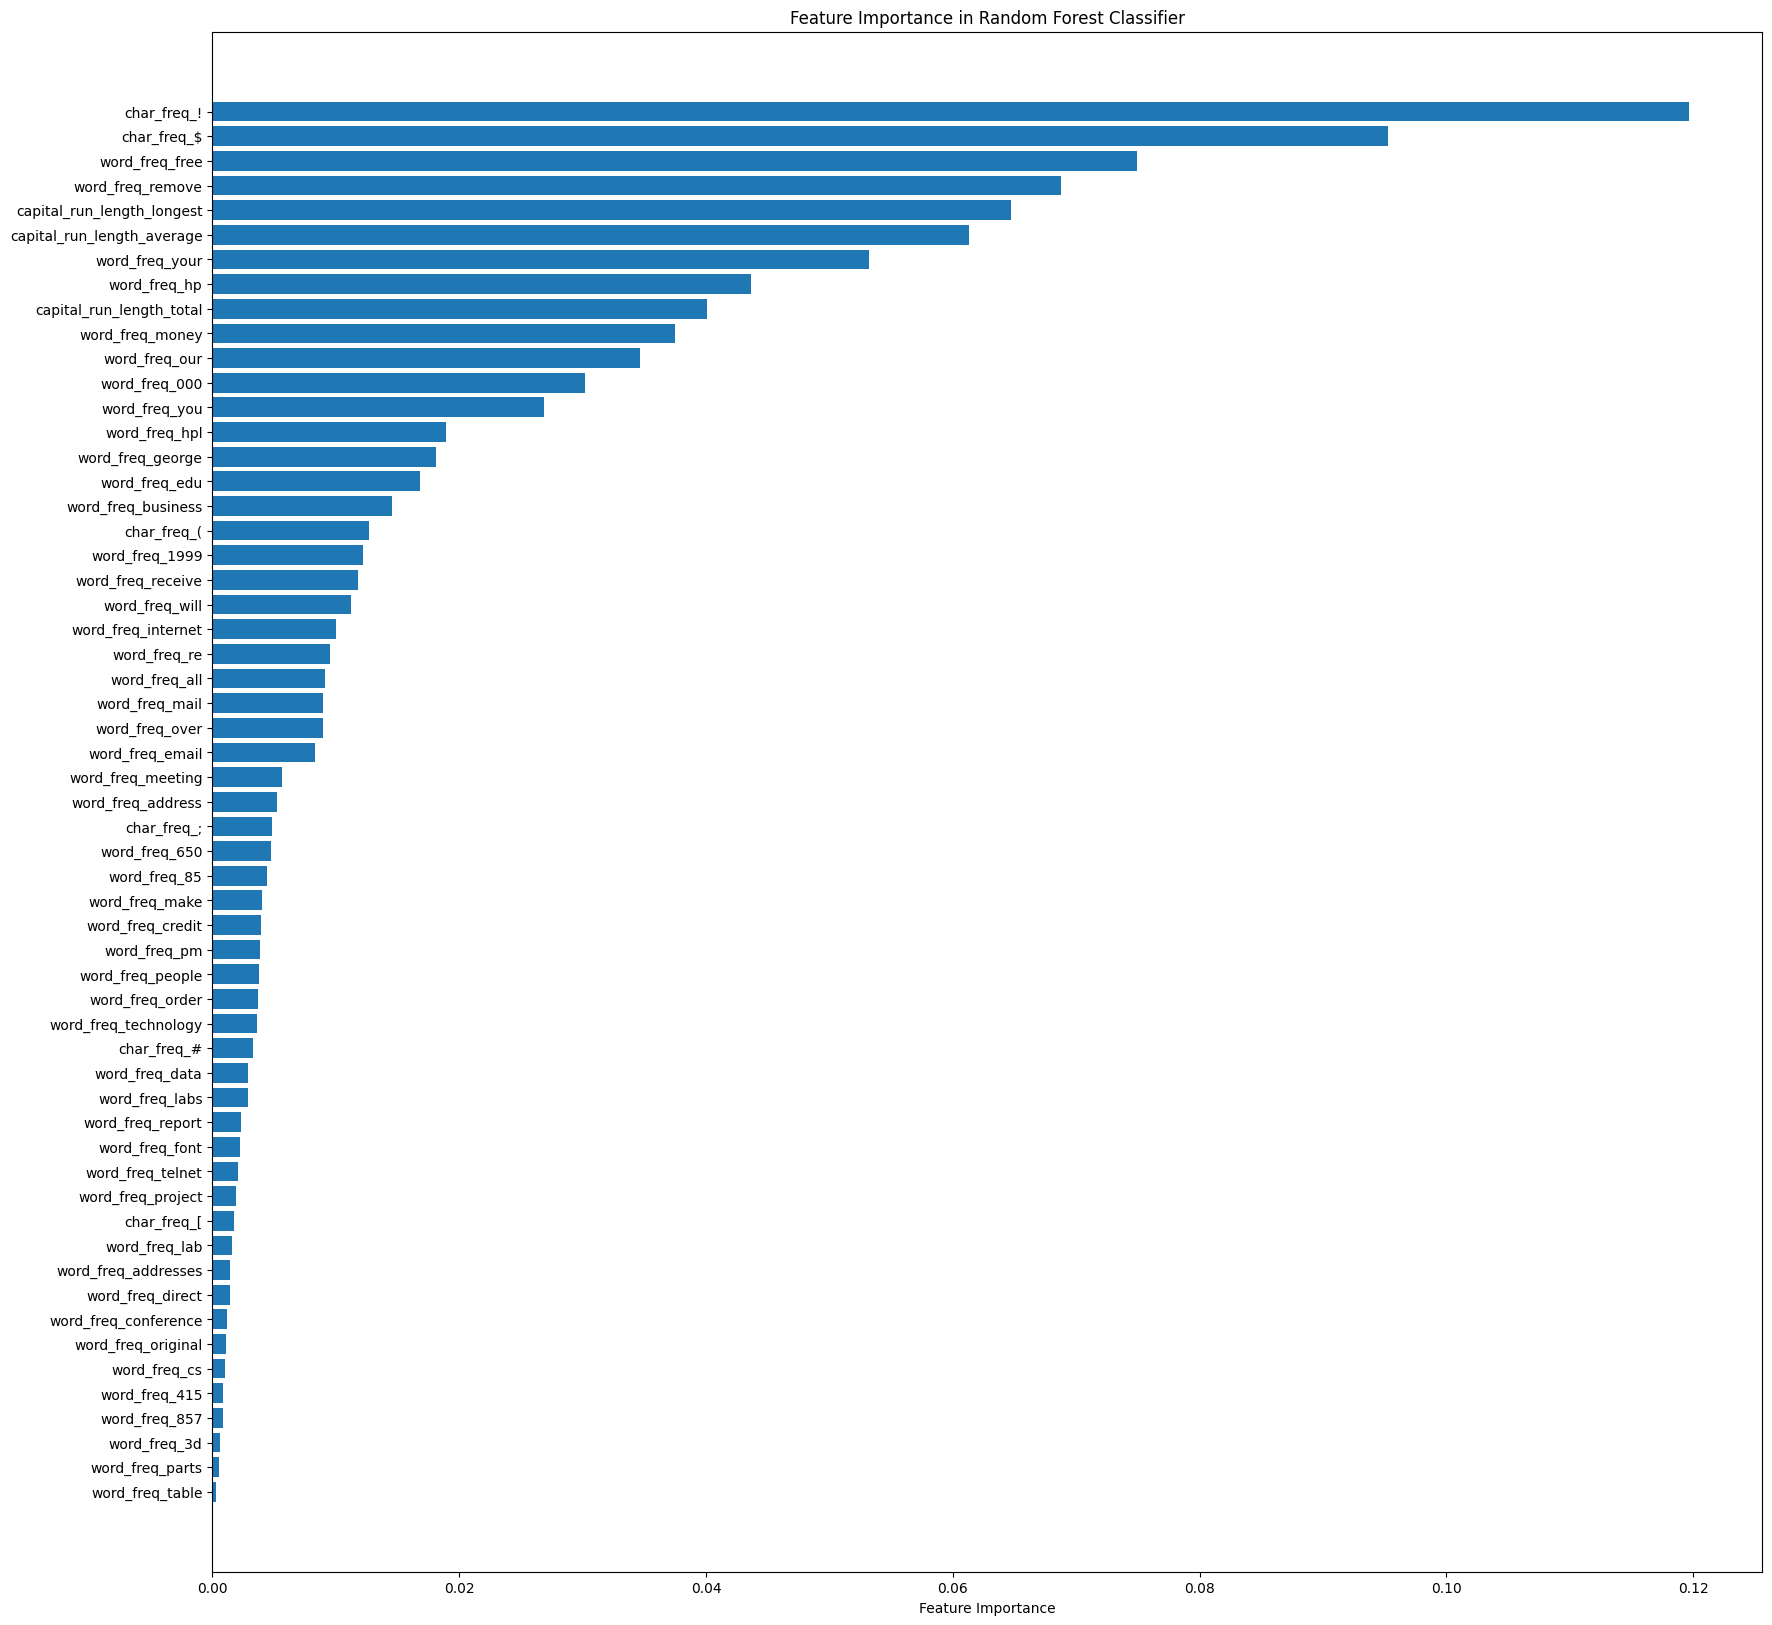

In [14]:
importances = rf.feature_importances_
col_imp = pd.DataFrame([list(cols[:57]), list(importances)]).T.rename(columns = {0:'feature', 1:'importance'}).sort_values('importance')

plt.figure(figsize = (20,20))
plt.barh(col_imp['feature'], col_imp['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

In [15]:
# pd.DataFrame([list(cols), list(feature_importances)]).T.rename(columns = {0:'feature', 1:'importance'})

In [16]:
# cols[min(feature_importances) == feature_importances]

In [17]:
# temp_cols = col_imp[:57]

# for i in range(2,57):
#     X = data[cols[:i]].values
#     acc, y_pred = randomForest(X,y)
#     acc_lst.append([i,acc*100])

In [18]:
# temp_cols = cols[:57]
# temp_cols

Now we can iterate through and remove the worst predictor from the model each iteration and find which the set of predictors produces the best model.

In [19]:
i = 57
temp_cols = np.array(cols[:57])
acc_lst = []
col_lst = []

while len(temp_cols) > 2:
    X = data[temp_cols].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=314)

    rf = RandomForestClassifier(n_estimators=100, random_state=314)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    importances = rf.feature_importances_
    # print(importances)
    # print(min(importances))
    # print(min(importances) == importances)
    # print(temp_cols)
    # print(temp_cols[min(importances) == importances])
    removal = temp_cols[min(importances) == importances]
    temp_cols = temp_cols[min(importances) != importances]
    acc_lst.append([
        len(temp_cols),
        acc*100,
        pre*100,
        rec*100,
        f1*100,
        removal[0]])
    col_lst.append(temp_cols)

Here we can see the number of predictors in a given model, the worst predictor and the scores for the model.

In [20]:
imp_acc = pd.DataFrame(acc_lst, columns = ['num_predictors', 'accuracy', 'precision', 'recall', 'f1', 'worst_predictor'])
imp_acc

,num_predictors,accuracy,precision,recall,f1,worst_predictor
0,56,95.482189,95.787140,92.903226,94.323144,word_freq_table
1,55,95.134666,96.371882,91.397849,93.818985,word_freq_3d
2,54,94.874023,95.111111,92.043011,93.551913,word_freq_415
3,53,95.308427,95.768374,92.473118,94.091904,word_freq_parts
4,52,95.047785,95.945946,91.612903,93.729373,word_freq_cs
5,51,94.960904,95.525727,91.827957,93.640351,word_freq_857
6,50,94.787142,94.900222,92.043011,93.449782,word_freq_conference
7,49,94.787142,94.900222,92.043011,93.449782,word_freq_direct
8,48,95.308427,96.179775,92.043011,94.065934,word_freq_lab
9,47,95.047785,95.739910,91.827957,93.743139,word_freq_addresses


After graphing the scores for each model we can see that after removing 42 predictors we have the best set of scores for the least number of predictors (14).

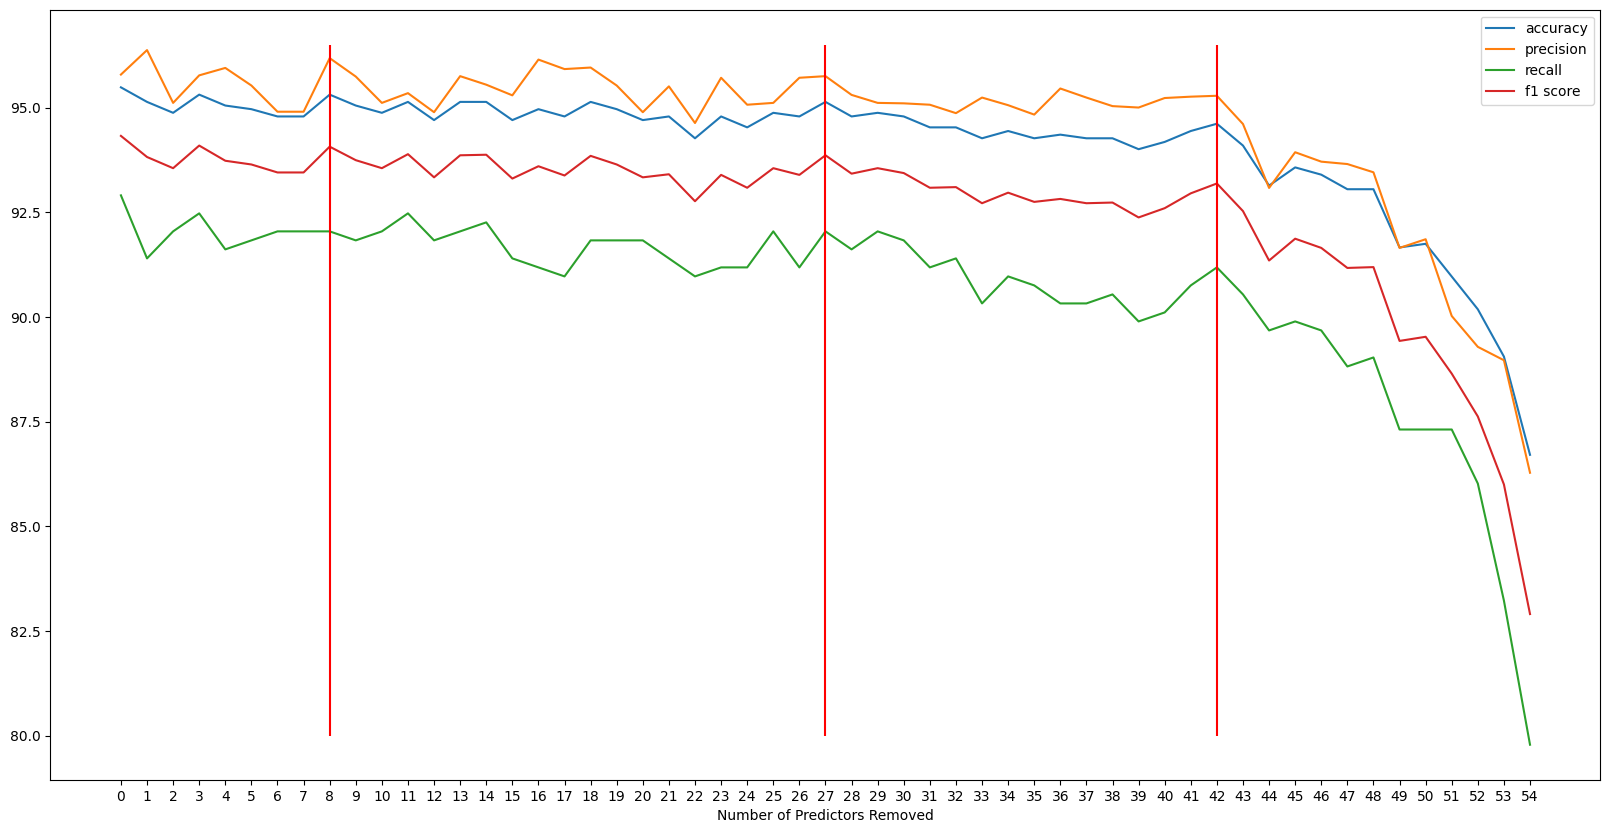

In [21]:
plt.figure(figsize = (20,10))
plt.plot(56-imp_acc['num_predictors'], imp_acc['accuracy'], label = 'accuracy')
plt.plot(56-imp_acc['num_predictors'], imp_acc['precision'], label = 'precision')
plt.plot(56-imp_acc['num_predictors'], imp_acc['recall'], label = 'recall')
plt.plot(56-imp_acc['num_predictors'], imp_acc['f1'], label = 'f1 score')

plt.title('' , size = 15)
plt.xlabel('Number of Predictors Removed', size = 10)
plt.ylabel('', size = 10)
plt.legend()

plt.xticks(np.arange(0, 55, 1)) 

plt.vlines(x=[8,27,42], ymin = 80, ymax = 96.5, color = 'red')
plt.show()

With an accuracy score of 94% we can see that a trimmed random forest model produces an extremely accurate spam filter with only 14 predictors. Using more complex methods could definitely improve this value but overall it performs well enough to accurately identify a vast majority of emails.

In [22]:
X = data[col_lst[42]].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=314)

rf = RandomForestClassifier(n_estimators=100, random_state=314)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)*100
pre = precision_score(y_test, y_pred)*100
rec = recall_score(y_test, y_pred)*100
f1  = f1_score(y_test, y_pred)*100

print('14 predictor trimmed random forest model:')
print('Accuracy score:  {:.2f}%'.format(acc))
print('Precision score: {:.2f}%'.format(pre))
print('Recall score:    {:.2f}%'.format(rec))
print('F1 score:        {:.2f}%'.format(f1))

14 predictor trimmed random forest model:
Accuracy score:  94.09%
Precision score: 94.61%
Recall score:    90.54%
F1 score:        92.53%
